In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import cvxpy as cp
import riskfolio as rp
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
closing_price_file = "/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/PX_LAST_Static.xlsx"
market_cap_file = '/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/CUR_MKT_CAP_Static.xlsx'
volume_file = '/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/PX_VOLUME_Static.xlsx'

# Load data
try:
    prices = pd.read_excel(closing_price_file, index_col=0)
    market_caps = pd.read_excel(market_cap_file, index_col=0)
    volumes = pd.read_excel(volume_file, index_col=0)
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# Convert index to datetime explicitly
try:
    prices.index = pd.to_datetime(prices.index, format='%m/%d/%Y', errors='coerce')
    market_caps.index = pd.to_datetime(market_caps.index, format='%m/%d/%Y', errors='coerce')
    volumes.index = pd.to_datetime(volumes.index, format='%m/%d/%Y', errors='coerce')
except Exception as e:
    print(f"Error converting index to datetime: {e}")
    raise

# Check for any invalid dates (NaT) in the index
if prices.index.isna().any():
    print("Warning: Some dates could not be parsed. Dropping invalid dates.")
    prices = prices[prices.index.notna()]
    market_caps = market_caps[market_caps.index.notna()]
    volumes = volumes[volumes.index.notna()]

# Ensure indices and columns align
prices = prices.sort_index()
market_caps = market_caps.sort_index().reindex(columns=prices.columns)
volumes = volumes.sort_index().reindex(columns=prices.columns)

# Check for missing data
if prices.isna().any().any() or market_caps.isna().any().any() or volumes.isna().any().any():
    print("Warning: Missing data detected. Filling with forward fill.")
    prices = prices.ffill()
    market_caps = market_caps.ffill()
    volumes = volumes.ffill()

# Debug: Inspect the index type and first few dates
print("Data loaded successfully.")
print(f"Index type: {type(prices.index)}")
print(f"First few index values: {prices.index[:5]}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"Number of stocks: {len(prices.columns)}")

Data loaded successfully.
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First few index values: DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date range: 2015-01-01 00:00:00 to 2025-03-24 00:00:00
Number of stocks: 153


In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Compute daily returns
returns = np.log(prices / prices.shift(1)).dropna()

# 1. Market Return (Nifty 200 index return)
market_weights = market_caps.div(market_caps.sum(axis=1), axis=0)
market_returns = (returns * market_weights).sum(axis=1)

# 2. Long-Term Momentum (63-day past return)
momentum_63d = np.log(prices / prices.shift(63)).dropna()

# 3. Medium-Term Momentum (21-day past return)
momentum_21d = np.log(prices / prices.shift(21)).dropna()

# 4. Mean Reversion (5-day past return, expecting reversal)
mean_reversion = np.log(prices / prices.shift(5)).dropna()

# 5. Market Momentum (21-day market return)
market_momentum = market_returns.rolling(window=21).sum().shift(1).dropna()

# 6. Volatility Trend (21-day volatility minus 63-day volatility)
volatility_21d = returns.rolling(window=21).std() * np.sqrt(252)
volatility_63d = returns.rolling(window=63).std() * np.sqrt(252)
volatility_trend = (volatility_21d - volatility_63d).dropna()

# 7. Market Trend (50-day vs. 200-day moving average of market returns)
market_prices = (market_returns + 1).cumprod()  # Convert returns to a price series
ma_50 = market_prices.rolling(window=50).mean()
ma_200 = market_prices.rolling(window=200).mean()
market_trend = ((ma_50 - ma_200) / ma_200).dropna()  # Relative difference
market_trend = (market_trend - market_trend.mean()) / market_trend.std()  # Normalize

# 8. Sector Momentum (Cluster stocks into sectors and compute average momentum)
momentum_21d_mean = momentum_21d.mean()
kmeans = KMeans(n_clusters=5, random_state=42)
sector_labels = kmeans.fit_predict(momentum_21d_mean.values.reshape(-1, 1))
sector_momentum = pd.DataFrame(index=momentum_21d.index, columns=momentum_21d.columns)
for stock in momentum_21d.columns:
    sector = sector_labels[momentum_21d.columns.get_loc(stock)]
    sector_stocks = momentum_21d.columns[sector_labels == sector]
    sector_momentum[stock] = momentum_21d[sector_stocks].mean(axis=1)
sector_momentum = sector_momentum.dropna()

# 9. Liquidity (Turnover: Volume * Price / Market Cap, normalized by 21-day average)
liquidity = (volumes * prices) / market_caps
liquidity = (liquidity / liquidity.rolling(window=21).mean()).dropna()

# 10. Size (Log of Market Cap, normalized)
size = np.log(market_caps)
size = (size - size.mean()) / size.std()  # Normalize
size = size.dropna()

# Align all data to the same dates
common_dates = returns.index.intersection(momentum_63d.index).intersection(momentum_21d.index).intersection(mean_reversion.index).intersection(market_momentum.index).intersection(volatility_trend.index).intersection(market_trend.index).intersection(sector_momentum.index).intersection(liquidity.index).intersection(size.index)
returns = returns.loc[common_dates]
market_returns = market_returns.loc[common_dates]
momentum_63d = momentum_63d.loc[common_dates]
momentum_21d = momentum_21d.loc[common_dates]
mean_reversion = mean_reversion.loc[common_dates]
market_momentum = market_momentum.loc[common_dates]
volatility_trend = volatility_trend.loc[common_dates]
market_trend = market_trend.loc[common_dates]
sector_momentum = sector_momentum.loc[common_dates]
liquidity = liquidity.loc[common_dates]
size = size.loc[common_dates]

print("Factors computed successfully.")
print(f"Aligned date range: {common_dates[0]} to {common_dates[-1]}")

Factors computed successfully.
Aligned date range: 2015-10-20 00:00:00 to 2025-03-24 00:00:00


In [5]:
from datetime import timedelta

# Define split dates
train_end = pd.to_datetime('2020-06-30')
val_end = pd.to_datetime('2021-12-31')
test_start = pd.to_datetime('2022-01-01')
test_end = pd.to_datetime('2025-03-18')

# Adjust split dates to the nearest available dates in the data
train_end = returns.index[returns.index <= train_end][-1] if any(returns.index <= train_end) else returns.index[0]
val_end = returns.index[returns.index <= val_end][-1] if any(returns.index <= val_end) else returns.index[-1]
test_start = returns.index[returns.index >= test_start][0] if any(returns.index >= test_start) else returns.index[-1]
test_end = returns.index[returns.index <= test_end][-1] if any(returns.index <= test_end) else returns.index[-1]

# Split returns
train_returns = returns.truncate(before=returns.index[0], after=train_end)
val_returns = returns.truncate(before=train_end + timedelta(days=1), after=val_end)
test_returns = returns.truncate(before=test_start, after=test_end)

# Split factors
train_factors = {
    'market': market_returns.truncate(before=market_returns.index[0], after=train_end),
    'momentum_63d': momentum_63d.truncate(before=momentum_63d.index[0], after=train_end),
    'momentum_21d': momentum_21d.truncate(before=momentum_21d.index[0], after=train_end),
    'mean_reversion': mean_reversion.truncate(before=mean_reversion.index[0], after=train_end),
    'market_momentum': market_momentum.truncate(before=market_momentum.index[0], after=train_end),
    'volatility_trend': volatility_trend.truncate(before=volatility_trend.index[0], after=train_end),
    'market_trend': market_trend.truncate(before=market_trend.index[0], after=train_end),
    'sector_momentum': sector_momentum.truncate(before=sector_momentum.index[0], after=train_end),
    'liquidity': liquidity.truncate(before=liquidity.index[0], after=train_end),
    'size': size.truncate(before=size.index[0], after=train_end)
}

val_factors = {
    'market': market_returns.truncate(before=train_end + timedelta(days=1), after=val_end),
    'momentum_63d': momentum_63d.truncate(before=train_end + timedelta(days=1), after=val_end),
    'momentum_21d': momentum_21d.truncate(before=train_end + timedelta(days=1), after=val_end),
    'mean_reversion': mean_reversion.truncate(before=train_end + timedelta(days=1), after=val_end),
    'market_momentum': market_momentum.truncate(before=train_end + timedelta(days=1), after=val_end),
    'volatility_trend': volatility_trend.truncate(before=train_end + timedelta(days=1), after=val_end),
    'market_trend': market_trend.truncate(before=train_end + timedelta(days=1), after=val_end),
    'sector_momentum': sector_momentum.truncate(before=train_end + timedelta(days=1), after=val_end),
    'liquidity': liquidity.truncate(before=train_end + timedelta(days=1), after=val_end),
    'size': size.truncate(before=train_end + timedelta(days=1), after=val_end)
}

test_factors = {
    'market': market_returns.truncate(before=test_start, after=test_end),
    'momentum_63d': momentum_63d.truncate(before=test_start, after=test_end),
    'momentum_21d': momentum_21d.truncate(before=test_start, after=test_end),
    'mean_reversion': mean_reversion.truncate(before=test_start, after=test_end),
    'market_momentum': market_momentum.truncate(before=test_start, after=test_end),
    'volatility_trend': volatility_trend.truncate(before=test_start, after=test_end),
    'market_trend': market_trend.truncate(before=test_start, after=test_end),
    'sector_momentum': sector_momentum.truncate(before=test_start, after=test_end),
    'liquidity': liquidity.truncate(before=test_start, after=test_end),
    'size': size.truncate(before=test_start, after=test_end)
}

print("Data split completed.")
print(f"Training: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Validation: {val_returns.index[0]} to {val_returns.index[-1]}")
print(f"Testing: {test_returns.index[0]} to {test_returns.index[-1]}")

Data split completed.
Training: 2015-10-20 00:00:00 to 2020-06-30 00:00:00
Validation: 2020-07-01 00:00:00 to 2021-12-31 00:00:00
Testing: 2022-01-03 00:00:00 to 2025-03-18 00:00:00


In [9]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def run_regression(stock_returns, factors, lookback=63, horizon=21):
    n_stocks = stock_returns.shape[1]
    n_days = len(stock_returns)
    if n_days <= lookback + horizon:
        raise ValueError(f"Lookback period ({lookback}) and horizon ({horizon}) are too large for the data length ({n_days}).")
    
    pred_dates = stock_returns.index[lookback:n_days - horizon + 1]
    predictions = pd.DataFrame(np.zeros((len(pred_dates), n_stocks)), index=pred_dates, columns=stock_returns.columns)
    residuals = pd.DataFrame(np.zeros((len(pred_dates), n_stocks)), index=pred_dates, columns=stock_returns.columns)
    
    scaler = StandardScaler()
    
    # Time decay weights (exponential decay with a half-life of 30 days)
    decay_factor = np.exp(-np.log(2) / 30)  # Half-life of 30 days
    weights = np.array([decay_factor ** i for i in range(lookback-1, -1, -1)])
    weights /= weights.sum()  # Normalize weights to sum to 1
    
    for t in range(lookback, n_days - horizon + 1):
        market_train = factors['market'].iloc[t-lookback:t].values.reshape(-1, 1)
        market_momentum_train = factors['market_momentum'].iloc[t-lookback:t].values.reshape(-1, 1)
        market_trend_train = factors['market_trend'].iloc[t-lookback:t].values.reshape(-1, 1)
        for i, stock in enumerate(stock_returns.columns):
            momentum_63d_train = factors['momentum_63d'][stock].iloc[t-lookback:t].values.reshape(-1, 1)
            momentum_21d_train = factors['momentum_21d'][stock].iloc[t-lookback:t].values.reshape(-1, 1)
            mean_reversion_train = factors['mean_reversion'][stock].iloc[t-lookback:t].values.reshape(-1, 1)
            volatility_trend_train = factors['volatility_trend'][stock].iloc[t-lookback:t].values.reshape(-1, 1)
            sector_momentum_train = factors['sector_momentum'][stock].iloc[t-lookback:t].values.reshape(-1, 1)
            
            X_train = np.hstack([market_train, market_momentum_train, market_trend_train, momentum_63d_train, momentum_21d_train, mean_reversion_train, volatility_trend_train, sector_momentum_train])
            X_train = scaler.fit_transform(X_train)  # Scale features
            y_train = stock_returns.iloc[t-lookback:t][stock].values
            
            model = Ridge(alpha=100.0)
            model.fit(X_train, y_train, sample_weight=weights)  # Apply time decay weights
            
            market_pred = factors['market'].iloc[t:t+1].values.reshape(1, -1)
            market_momentum_pred = factors['market_momentum'].iloc[t:t+1].values.reshape(1, -1)
            market_trend_pred = factors['market_trend'].iloc[t:t+1].values.reshape(1, -1)
            momentum_63d_pred = factors['momentum_63d'][stock].iloc[t:t+1].values.reshape(1, -1)
            momentum_21d_pred = factors['momentum_21d'][stock].iloc[t:t+1].values.reshape(1, -1)
            mean_reversion_pred = factors['mean_reversion'][stock].iloc[t:t+1].values.reshape(1, -1)
            volatility_trend_pred = factors['volatility_trend'][stock].iloc[t:t+1].values.reshape(1, -1)
            sector_momentum_pred = factors['sector_momentum'][stock].iloc[t:t+1].values.reshape(1, -1)
            X_pred = np.hstack([market_pred, market_momentum_pred, market_trend_pred, momentum_63d_pred, momentum_21d_pred, mean_reversion_pred, volatility_trend_pred, sector_momentum_pred])
            X_pred = scaler.transform(X_pred)
            
            pred = model.predict(X_pred)[0]
            predictions.iloc[t - lookback, i] = pred * horizon
            residuals.iloc[t - lookback, i] = np.var(y_train - model.predict(X_train))
    
    return predictions, residuals

# Run regression on training + validation data to tune lookback
train_val_returns = pd.concat([train_returns, val_returns])
train_val_factors = {
    'market': pd.concat([train_factors['market'], val_factors['market']]),
    'momentum_63d': pd.concat([train_factors['momentum_63d'], val_factors['momentum_63d']]),
    'momentum_21d': pd.concat([train_factors['momentum_21d'], val_factors['momentum_21d']]),
    'mean_reversion': pd.concat([train_factors['mean_reversion'], val_factors['mean_reversion']]),
    'market_momentum': pd.concat([train_factors['market_momentum'], val_factors['market_momentum']]),
    'volatility_trend': pd.concat([train_factors['volatility_trend'], val_factors['volatility_trend']]),
    'market_trend': pd.concat([train_factors['market_trend'], val_factors['market_trend']]),
    'sector_momentum': pd.concat([train_factors['sector_momentum'], val_factors['sector_momentum']]),
    'liquidity': pd.concat([train_factors['liquidity'], val_factors['liquidity']]),
    'size': pd.concat([train_factors['size'], val_factors['size']])
}

print(f"Length of val_returns: {len(val_returns)}")
print(f"Validation period: {val_returns.index[0]} to {val_returns.index[-1]}")

max_lookback = len(val_returns) - 21
lookback_options = [21, 63, 126]
best_lookback = lookback_options[0]
best_mse = float('inf')

for lookback in lookback_options:
    if lookback < 1 or lookback > max_lookback:
        continue
    print(f"Testing lookback: {lookback}")
    preds, _ = run_regression(val_returns, val_factors, lookback=lookback, horizon=21)
    true_21d_returns = val_returns.shift(-21).dropna()
    
    common_dates = preds.index.intersection(true_21d_returns.index)
    if len(common_dates) == 0:
        print(f"No overlapping dates for lookback {lookback}. Skipping.")
        continue
    preds_aligned = preds.loc[common_dates].values
    true_aligned = true_21d_returns.loc[common_dates].values
    
    mse = np.mean((preds_aligned - true_aligned)**2)
    print(f"MSE for lookback {lookback}: {mse}")
    if mse < best_mse:
        best_mse = mse
        best_lookback = lookback

print(f"Best lookback period: {best_lookback} days (MSE: {best_mse})")

Length of val_returns: 377
Validation period: 2020-07-01 00:00:00 to 2021-12-31 00:00:00
Testing lookback: 21
MSE for lookback 21: 0.015196188208744351
Testing lookback: 63
MSE for lookback 63: 0.006856168760613858
Testing lookback: 126
MSE for lookback 126: 0.0055069706463515495
Best lookback period: 126 days (MSE: 0.0055069706463515495)


In [15]:
import numpy as np
import cvxpy as cp
from sklearn.covariance import LedoitWolf

def black_litterman(returns, Q, Omega, P, t, tau=0.005, delta=2.5):
    if not isinstance(returns, pd.DataFrame):
        raise ValueError(f"Expected returns to be a DataFrame, got {type(returns)}")
    if returns.shape[0] < 2:
        raise ValueError(f"Expected at least 2 rows in returns, got {returns.shape[0]} rows")
    if returns.shape[1] < 1:
        raise ValueError(f"Expected at least 1 column in returns, got {returns.shape[1]} columns")
    
    lw = LedoitWolf()
    Sigma = lw.fit(returns).covariance_
    eigenvalues = np.linalg.eigvals(Sigma)
    if np.any(eigenvalues < 0):
        adjustment = abs(np.min(eigenvalues)) + 1e-4
        print(f"Iteration t={t}: Covariance matrix not positive semi-definite. Min eigenvalue: {np.min(eigenvalues)}. Adjusting with {adjustment}...")
        Sigma = Sigma + np.eye(Sigma.shape[0]) * adjustment
    
    market_weights = market_caps.loc[returns.index].mean().div(market_caps.loc[returns.index].mean().sum())
    Pi = delta * Sigma @ market_weights.values
    
    Omega_inv = np.linalg.inv(Omega)
    Sigma_inv = np.linalg.inv(Sigma)
    mu_bl = np.linalg.inv(P.T @ Omega_inv @ P + Sigma_inv / tau) @ (P.T @ Omega_inv @ Q + Sigma_inv @ Pi / tau)
    return mu_bl, Sigma, delta

def optimize_portfolio(mu, Sigma, delta):
    n = len(mu)
    w = cp.Variable(n)
    Sigma_psd = cp.psd_wrap(Sigma)
    objective = cp.Maximize(w @ mu - 0.5 * delta * cp.quad_form(w, Sigma_psd))
    constraints = [cp.sum(w) == 1, w >= 0, w <= 0.5]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return w.value

# Rebalancing setting
rebalance_rule = '95_percent_or_63_days'
min_predicted_return = 0.005  # Minimum predicted portfolio return (0.5% over 21 days) to trigger rebalancing

# Black-Litterman portfolio
portfolio_value = 1_000_000
portfolio_values = [portfolio_value]
weights_history = []
dates = test_returns.index
initial_weights = np.ones(len(test_returns.columns)) / len(test_returns.columns)
current_weights = initial_weights.copy()
cash = 0
days_since_rebalance = 0
rebalance_freq = 21

# Equal-weight portfolio
equal_weights = np.ones(len(test_returns.columns)) / len(test_returns.columns)
equal_portfolio_value = 1_000_000
equal_portfolio_values = [equal_portfolio_value]
equal_portfolio_returns = []

# Mean-Variance Optimization (MVO) portfolio
mvo_portfolio_value = 1_000_000
mvo_portfolio_values = [mvo_portfolio_value]
mvo_weights = np.ones(len(test_returns.columns)) / len(test_returns.columns)
mvo_initial_weights = mvo_weights.copy()
mvo_days_since_rebalance = 0
mvo_portfolio_returns = []

# Store portfolio returns for visualization
portfolio_returns = []

horizon = 21
start_t = best_lookback + horizon

for t in range(start_t, len(test_returns) - horizon):
    date = dates[t]
    window_returns = test_returns.iloc[t-best_lookback-horizon:t+1]
    window_factors = {
        'market': test_factors['market'].iloc[t-best_lookback-horizon:t+1],
        'momentum_63d': test_factors['momentum_63d'].iloc[t-best_lookback-horizon:t+1],
        'momentum_21d': test_factors['momentum_21d'].iloc[t-best_lookback-horizon:t+1],
        'mean_reversion': test_factors['mean_reversion'].iloc[t-best_lookback-horizon:t+1],
        'market_momentum': test_factors['market_momentum'].iloc[t-best_lookback-horizon:t+1],
        'volatility_trend': test_factors['volatility_trend'].iloc[t-best_lookback-horizon:t+1],
        'market_trend': test_factors['market_trend'].iloc[t-best_lookback-horizon:t+1],
        'sector_momentum': test_factors['sector_momentum'].iloc[t-best_lookback-horizon:t+1],
        'liquidity': test_factors['liquidity'].iloc[t-best_lookback-horizon:t+1],
        'size': test_factors['size'].iloc[t-best_lookback-horizon:t+1]
    }
    
    print(f"Iteration t={t}, window_returns shape: {window_returns.shape}")
    
    if window_returns.shape[0] < 2:
        print(f"Skipping t={t}: window_returns has {window_returns.shape[0]} rows, need at least 2")
        daily_returns = test_returns.iloc[t].values
        portfolio_return = np.sum(current_weights * daily_returns)
        portfolio_value = portfolio_value * (1 + portfolio_return)
        portfolio_values.append(portfolio_value)
        portfolio_returns.append(portfolio_return)
        
        equal_portfolio_return = np.sum(equal_weights * daily_returns)
        equal_portfolio_value = equal_portfolio_value * (1 + equal_portfolio_return)
        equal_portfolio_values.append(equal_portfolio_value)
        equal_portfolio_returns.append(equal_portfolio_return)
        
        mvo_portfolio_return = np.sum(mvo_weights * daily_returns)
        mvo_portfolio_value = mvo_portfolio_value * (1 + mvo_portfolio_return)
        mvo_portfolio_values.append(mvo_portfolio_value)
        mvo_portfolio_returns.append(mvo_portfolio_return)
        
        current_weights = (current_weights * (1 + daily_returns)) / (1 + np.sum(current_weights * daily_returns))
        mvo_weights = (mvo_weights * (1 + daily_returns)) / (1 + np.sum(mvo_weights * daily_returns))
        weights_history.append(current_weights.copy())
        days_since_rebalance += 1
        mvo_days_since_rebalance += 1
        continue
    
    # Black-Litterman: Regression-based Q
    Q_df, residuals_df = run_regression(window_returns, window_factors, lookback=best_lookback, horizon=21)
    Q = Q_df.iloc[-1].values
    omega_diagonal = residuals_df.iloc[-1].values * 21
    Omega = np.diag(omega_diagonal)
    P = np.eye(len(test_returns.columns))
    
    # Compute predicted portfolio return and market trend
    predicted_portfolio_return = np.sum(current_weights * Q)
    current_market_trend = window_factors['market_trend'].iloc[-1]
    
    actual_21d_returns = test_returns.iloc[t:t+21].sum().values if t+21 <= len(test_returns) else test_returns.iloc[t:].sum().values
    print(f"t={t}, Predicted 21d Return (Avg): {Q.mean():.4f}, Actual 21d Return (Avg): {actual_21d_returns.mean():.4f}")
    
    mu_bl, Sigma, delta = black_litterman(window_returns, Q, Omega, P, t)
    new_weights = optimize_portfolio(mu_bl, Sigma, delta)
    
    # MVO: Use historical mean returns as expected returns
    mu_mvo = window_returns.mean().values * 252
    lw = LedoitWolf()
    Sigma_mvo = lw.fit(window_returns).covariance_
    mvo_new_weights = optimize_portfolio(mu_mvo, Sigma_mvo, delta)
    
    daily_returns = test_returns.iloc[t].values
    portfolio_return = np.sum(current_weights * daily_returns)
    portfolio_value = portfolio_value * (1 + portfolio_return)
    portfolio_values.append(portfolio_value)
    portfolio_returns.append(portfolio_return)
    
    equal_portfolio_return = np.sum(equal_weights * daily_returns)
    equal_portfolio_value = equal_portfolio_value * (1 + equal_portfolio_return)
    equal_portfolio_values.append(equal_portfolio_value)
    equal_portfolio_returns.append(equal_portfolio_return)
    
    mvo_portfolio_return = np.sum(mvo_weights * daily_returns)
    mvo_portfolio_value = mvo_portfolio_value * (1 + mvo_portfolio_return)
    mvo_portfolio_values.append(mvo_portfolio_value)
    mvo_portfolio_returns.append(mvo_portfolio_return)
    
    current_weights = (current_weights * (1 + daily_returns)) / (1 + np.sum(current_weights * daily_returns))
    mvo_weights = (mvo_weights * (1 + daily_returns)) / (1 + np.sum(mvo_weights * daily_returns))
    
    days_since_rebalance += 1
    mvo_days_since_rebalance += 1
    weight_change = np.abs(current_weights - initial_weights) / initial_weights
    mvo_weight_change = np.abs(mvo_weights - mvo_initial_weights) / mvo_initial_weights
    
    should_rebalance = False
    if rebalance_rule == '95_percent_or_63_days':
        # Only rebalance if predicted return is positive and market trend is not bearish
        should_rebalance = (np.any(weight_change > 0.60) or days_since_rebalance >= rebalance_freq) and predicted_portfolio_return > min_predicted_return and current_market_trend > 0
    
    if should_rebalance:
        current_weights = new_weights.copy()
        initial_weights = new_weights.copy()
        days_since_rebalance = 0
        top_stocks = np.argsort(new_weights)[-5:]
        print(f"BL Rebalanced on {date} (Weight change: {np.max(weight_change):.2%}, Days since last: {days_since_rebalance}, Predicted Portfolio Return: {predicted_portfolio_return:.4f}, Market Trend: {current_market_trend:.4f})")
        print(f"Top 5 weights: {[(test_returns.columns[i], new_weights[i]) for i in top_stocks]}")
    
    mvo_should_rebalance = False
    if rebalance_rule == '95_percent_or_63_days':
        mvo_should_rebalance = np.any(mvo_weight_change > 0.95) or mvo_days_since_rebalance >= rebalance_freq
    
    if mvo_should_rebalance:
        mvo_weights = mvo_new_weights.copy()
        mvo_initial_weights = mvo_new_weights.copy()
        mvo_days_since_rebalance = 0
        top_stocks = np.argsort(mvo_new_weights)[-5:]
        print(f"MVO Rebalanced on {date} (Weight change: {np.max(mvo_weight_change):.2%}, Days since last: {mvo_days_since_rebalance})")
        print(f"Top 5 weights: {[(test_returns.columns[i], mvo_new_weights[i]) for i in top_stocks]}")
    
    weights_history.append(current_weights.copy())

Iteration t=147, window_returns shape: (148, 153)
t=147, Predicted 21d Return (Avg): -0.0137, Actual 21d Return (Avg): 0.0491
Iteration t=148, window_returns shape: (148, 153)
t=148, Predicted 21d Return (Avg): -0.0066, Actual 21d Return (Avg): 0.0506
Iteration t=149, window_returns shape: (148, 153)
t=149, Predicted 21d Return (Avg): -0.0052, Actual 21d Return (Avg): 0.0516
Iteration t=150, window_returns shape: (148, 153)
t=150, Predicted 21d Return (Avg): -0.0026, Actual 21d Return (Avg): 0.0502
Iteration t=151, window_returns shape: (148, 153)
t=151, Predicted 21d Return (Avg): -0.0056, Actual 21d Return (Avg): 0.0594
Iteration t=152, window_returns shape: (148, 153)
t=152, Predicted 21d Return (Avg): -0.0059, Actual 21d Return (Avg): 0.0543
Iteration t=153, window_returns shape: (148, 153)
t=153, Predicted 21d Return (Avg): -0.0055, Actual 21d Return (Avg): 0.0495
Iteration t=154, window_returns shape: (148, 153)
t=154, Predicted 21d Return (Avg): 0.0001, Actual 21d Return (Avg): 

/var/folders/rk/ldn3jjlj2kzf72xtkfcdtx400000gn/T/ipykernel_3558/3438632158.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sector_weights = sector_weights.fillna(0)


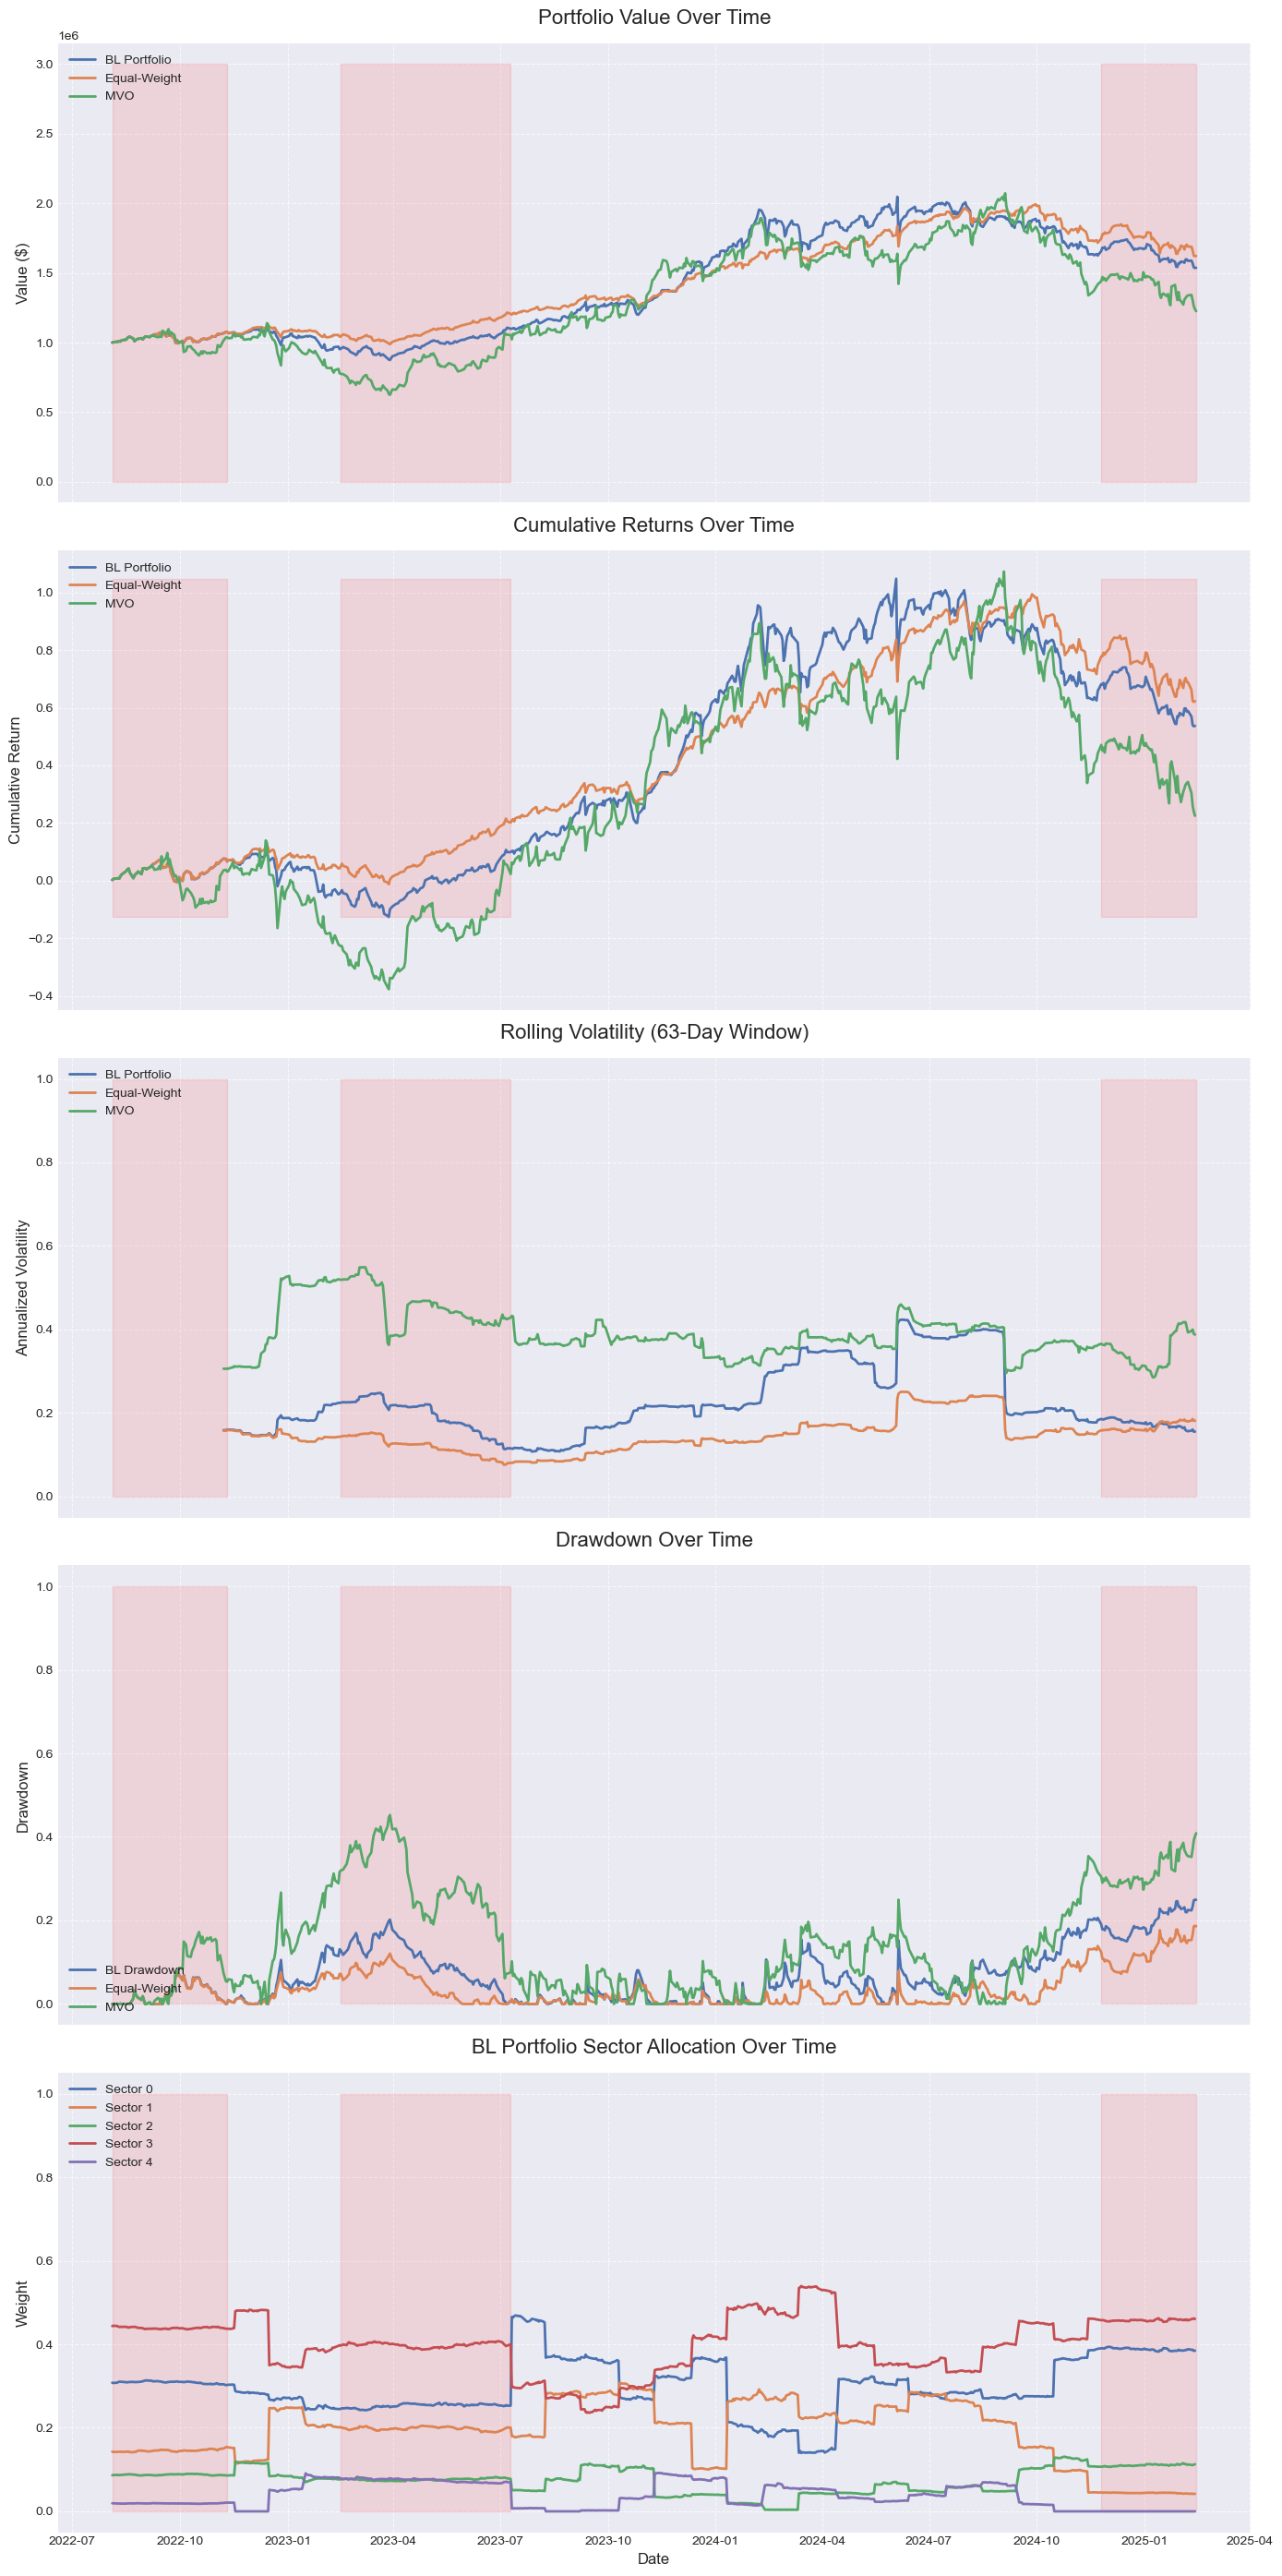

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a more visually appealing style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")

risk_free_rate_annual = 0.068
risk_free_rate_daily = risk_free_rate_annual / 252

# Convert portfolio values and returns to Series
portfolio_value_series = pd.Series(portfolio_values, index=dates[best_lookback+horizon:len(portfolio_values)+best_lookback+horizon])
equal_portfolio_value_series = pd.Series(equal_portfolio_values, index=dates[best_lookback+horizon:len(equal_portfolio_values)+best_lookback+horizon])
mvo_portfolio_value_series = pd.Series(mvo_portfolio_values, index=dates[best_lookback+horizon:len(mvo_portfolio_values)+best_lookback+horizon])
portfolio_returns_series = pd.Series(portfolio_returns, index=dates[best_lookback+horizon:len(portfolio_values)+best_lookback+horizon-1])
equal_portfolio_returns_series = pd.Series(equal_portfolio_returns, index=dates[best_lookback+horizon:len(equal_portfolio_values)+best_lookback+horizon-1])
mvo_portfolio_returns_series = pd.Series(mvo_portfolio_returns, index=dates[best_lookback+horizon:len(mvo_portfolio_values)+best_lookback+horizon-1])

# Align market trend data for shading bearish periods
market_trend_series = test_factors['market_trend'].reindex(portfolio_value_series.index)

fig, axs = plt.subplots(5, 1, figsize=(14, 28), sharex=True)

# 1. Portfolio Value Over Time
axs[0].plot(portfolio_value_series.index, portfolio_value_series, label='BL Portfolio', linewidth=2)
axs[0].plot(equal_portfolio_value_series.index, equal_portfolio_value_series, label='Equal-Weight', linewidth=2)
axs[0].plot(mvo_portfolio_value_series.index, mvo_portfolio_value_series, label='MVO', linewidth=2)
axs[0].set_title('Portfolio Value Over Time', fontsize=16, pad=15)
axs[0].set_ylabel('Value ($)', fontsize=12)
axs[0].legend(loc='upper left', fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].fill_between(market_trend_series.index, 0, 3e6, where=market_trend_series < 0, color='red', alpha=0.1, label='Bearish Market Periods')

# 2. Cumulative Returns Over Time
cumulative_returns = (1 + portfolio_returns_series).cumprod() - 1
equal_cumulative_returns = (1 + equal_portfolio_returns_series).cumprod() - 1
mvo_cumulative_returns = (1 + mvo_portfolio_returns_series).cumprod() - 1
axs[1].plot(cumulative_returns.index, cumulative_returns, label='BL Portfolio', linewidth=2)
axs[1].plot(equal_cumulative_returns.index, equal_cumulative_returns, label='Equal-Weight', linewidth=2)
axs[1].plot(mvo_cumulative_returns.index, mvo_cumulative_returns, label='MVO', linewidth=2)
axs[1].set_title('Cumulative Returns Over Time', fontsize=16, pad=15)
axs[1].set_ylabel('Cumulative Return', fontsize=12)
axs[1].legend(loc='upper left', fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].fill_between(market_trend_series.index, cumulative_returns.min(), cumulative_returns.max(), where=market_trend_series < 0, color='red', alpha=0.1)

# 3. Rolling Volatility (63-day window)
rolling_vol = portfolio_returns_series.rolling(window=63).std() * np.sqrt(252)
equal_rolling_vol = equal_portfolio_returns_series.rolling(window=63).std() * np.sqrt(252)
mvo_rolling_vol = mvo_portfolio_returns_series.rolling(window=63).std() * np.sqrt(252)
axs[2].plot(rolling_vol.index, rolling_vol, label='BL Portfolio', linewidth=2)
axs[2].plot(equal_rolling_vol.index, equal_rolling_vol, label='Equal-Weight', linewidth=2)
axs[2].plot(mvo_rolling_vol.index, mvo_rolling_vol, label='MVO', linewidth=2)
axs[2].set_title('Rolling Volatility (63-Day Window)', fontsize=16, pad=15)
axs[2].set_ylabel('Annualized Volatility', fontsize=12)
axs[2].legend(loc='upper left', fontsize=10)
axs[2].grid(True, linestyle='--', alpha=0.7)
axs[2].fill_between(market_trend_series.index, 0, 1, where=market_trend_series < 0, color='red', alpha=0.1)

# 4. Drawdown Over Time
drawdown = (portfolio_value_series.cummax() - portfolio_value_series) / portfolio_value_series.cummax()
equal_drawdown = (equal_portfolio_value_series.cummax() - equal_portfolio_value_series) / equal_portfolio_value_series.cummax()
mvo_drawdown = (mvo_portfolio_value_series.cummax() - mvo_portfolio_value_series) / mvo_portfolio_value_series.cummax()
axs[3].plot(drawdown.index, drawdown, label='BL Drawdown', linewidth=2)
axs[3].plot(equal_drawdown.index, equal_drawdown, label='Equal-Weight', linewidth=2)
axs[3].plot(mvo_drawdown.index, mvo_drawdown, label='MVO', linewidth=2)
axs[3].set_title('Drawdown Over Time', fontsize=16, pad=15)
axs[3].set_ylabel('Drawdown', fontsize=12)
axs[3].legend(loc='lower left', fontsize=10)
axs[3].grid(True, linestyle='--', alpha=0.7)
axs[3].fill_between(market_trend_series.index, 0, 1, where=market_trend_series < 0, color='red', alpha=0.1)

# 5. Sector Allocation Over Time (BL Portfolio)
weights_df = pd.DataFrame(weights_history, index=dates[best_lookback+horizon:len(weights_history)+best_lookback+horizon], columns=test_returns.columns)
sector_weights = pd.DataFrame(index=weights_df.index, columns=[f'Sector {i}' for i in range(5)])
for t in range(len(weights_df)):
    for stock in weights_df.columns:
        sector = sector_labels[weights_df.columns.get_loc(stock)]
        sector_weights.iloc[t, sector] = sector_weights.iloc[t, sector] + weights_df.iloc[t][stock] if not pd.isna(sector_weights.iloc[t, sector]) else weights_df.iloc[t][stock]
sector_weights = sector_weights.fillna(0)
for sector in sector_weights.columns:
    axs[4].plot(sector_weights.index, sector_weights[sector], label=sector, linewidth=2)
axs[4].set_title('BL Portfolio Sector Allocation Over Time', fontsize=16, pad=15)
axs[4].set_xlabel('Date', fontsize=12)
axs[4].set_ylabel('Weight', fontsize=12)
axs[4].legend(loc='upper left', fontsize=10)
axs[4].grid(True, linestyle='--', alpha=0.7)
axs[4].fill_between(market_trend_series.index, 0, 1, where=market_trend_series < 0, color='red', alpha=0.1)

plt.tight_layout()
plt.show()